In [2]:
# bmi calculator workflow

In [18]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Optional

In [19]:
class BMIState(BaseModel):
    weight : float
    height : float
    bmi: Optional[float] = None 

In [20]:
def calculate_bmi(state : BMIState) -> BMIState:
    weight = state.weight
    height = state.height

    state.bmi = round(weight / (height**2), 2)

    return state

In [21]:
# Define graph
graph = StateGraph(BMIState)

# add node to your graph
graph.add_node('calculate_bmi', calculate_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)


# compile the graph
workflow = graph.compile()

In [22]:
# execute the graph
output_state = workflow.invoke({'weight':68, 'height': 5.8})

print(output_state)


{'weight': 68.0, 'height': 5.8, 'bmi': 2.02}


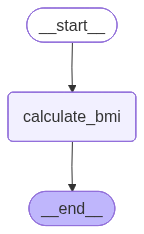

In [23]:
# see the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [27]:
# lets extend functonality and tell if the persion is obis:

class BMIState(BaseModel):
    weight : float
    height : float
    bmi: Optional[float] = None 
    category : Optional[str] = None

In [28]:
def category_check(state : BMIState) -> BMIState:
    bmi = state.bmi
    if bmi < 18.5:
        state.category = "UnderWeight"
    elif bmi > 18.5 and bmi < 25:
        state.category = "Normal"
    else :
        state.category = "OverWeight"
    return state

In [29]:
# Define graph
graph = StateGraph(BMIState)

# add node to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('category_check', category_check)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'category_check')
graph.add_edge('category_check', END)


# compile the graph
workflow = graph.compile()

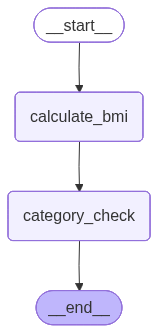

In [30]:
# see the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [31]:
# execute the graph
output_state = workflow.invoke({'weight':68, 'height': 5.8})

print(output_state)

{'weight': 68.0, 'height': 5.8, 'bmi': 2.02, 'category': 'UnderWeight'}
